# Feature Selection

This notebook identifies the most informative financial variables for fraud detection.

The goals of this stage are to:

- remove irrelevant or redundant variables,
- reduce multicollinearity,
- retain features with predictive value for fraud detection,
- prepare a final dataset for model development.

In [1]:
from pathlib import Path
from IPython.display import display

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import VarianceThreshold, mutual_info_classif

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

DATA_PATH = Path("../data")
df = pd.read_excel(DATA_PATH / "processed_data.xlsx")

print("Shape:", df.shape)
display(df.head())

Shape: (1906, 32)


,CP,Năm,DSRI,GMI,AQI,SGI,DEPI,SGAI,LVGI,TATA,...,Receivables_to_Revenue,Receivables_to_Assets,Inventory_to_Assets,Current_Assets_to_Total_Assets,CFO_to_Assets,CFO_to_Revenue,Accruals_to_Assets,Working_Capital_to_Assets,Firm_Size,Fraud
0,VGI,2018,1.084421,1.046653,1.029731,0.886654,0.884559,0.959822,0.889766,-0.101945,...,0.413736,0.120602,0.061870,0.397922,0.083650,0.286968,-0.101945,0.090983,31.689111,1
1,AGM,2018,1.097927,1.008271,1.340456,0.919842,0.788457,1.078348,0.633748,-0.142846,...,0.027918,0.104887,0.493065,0.732636,0.192490,0.051235,-0.142846,0.426104,27.036548,0
2,BKC,2018,0.841932,0.952255,1.080715,0.987486,0.537917,0.965435,1.197318,0.088754,...,0.128463,0.078563,0.413480,0.504713,-0.119212,-0.194930,0.088754,-0.005270,26.411455,0
3,VGS,2018,0.743001,0.993651,1.622708,1.157163,1.588574,0.717813,0.847319,-0.175852,...,0.087645,0.427095,0.266418,0.713469,0.207064,0.042492,-0.175852,0.156610,27.981720,0
4,VNG,2018,1.183387,1.019476,0.904722,0.993112,0.958951,1.122113,1.145842,-0.036049,...,0.514868,0.255890,0.006239,0.311328,0.061342,0.123425,-0.036049,0.096571,28.246052,0


## Define Features and Target

We exclude identifier and time-related columns from the feature set.  
The target variable is `Fraud`.

In [2]:
target_col = "Fraud"
exclude_cols = ["CP", "Năm", target_col]

feature_cols = [col for col in df.columns if col not in exclude_cols]

X = df[feature_cols].copy()
y = df[target_col].copy()

print("Number of candidate features:", len(feature_cols))
print(feature_cols)

Number of candidate features: 29
['DSRI', 'GMI', 'AQI', 'SGI', 'DEPI', 'SGAI', 'LVGI', 'TATA', 'RSST_Accruals', 'Delta_Receivables', 'Delta_Inventory', 'Delta_ROA', 'Soft_Assets', 'ROA', 'ROE', 'Net_Profit_Margin', 'Gross_Profit_Margin', 'Revenue_Growth', 'Debt_to_Assets', 'Debt_to_Equity', 'Receivables_to_Revenue', 'Receivables_to_Assets', 'Inventory_to_Assets', 'Current_Assets_to_Total_Assets', 'CFO_to_Assets', 'CFO_to_Revenue', 'Accruals_to_Assets', 'Working_Capital_to_Assets', 'Firm_Size']


## Basic Data Check

Before selecting variables, we verify missing values and review the basic structure of the candidate feature set.

In [3]:
print("Missing values in candidate features:")
display(X.isna().sum().sort_values(ascending=False).head(10))

print("\nFeature summary:")
display(X.describe().T.head())

Missing values in candidate features:


DSRI                 0
GMI                  0
AQI                  0
SGI                  0
DEPI                 0
SGAI                 0
LVGI                 0
TATA                 0
RSST_Accruals        0
Delta_Receivables    0
dtype: int64


Feature summary:


,count,mean,std,min,25%,50%,75%,max
DSRI,1906.0,1.321709,1.268722,0.163107,0.817100,1.030031,1.346200,9.946109
GMI,1906.0,1.001029,0.055491,0.804298,0.986436,0.998595,1.011712,1.289855
AQI,1906.0,1.203525,1.017529,0.060940,0.839659,1.008425,1.198603,7.998792
SGI,1906.0,1.079868,0.523812,0.111430,0.855166,1.021055,1.185523,4.002145
DEPI,1906.0,1.008272,0.511708,0.000000,0.868191,0.950891,1.047367,4.123804


## Low-Variance Filtering

Features with extremely low variance provide little discriminatory information.  
We first remove near-constant variables using a variance threshold.

In [4]:
vt = VarianceThreshold(threshold=0.0001)
vt.fit(X)

vt_features = X.columns[vt.get_support()].tolist()
removed_low_variance = [col for col in X.columns if col not in vt_features]

X_vt = X[vt_features].copy()

print("Features after variance filtering:", len(vt_features))
print("Removed low-variance features:", removed_low_variance if removed_low_variance else "None")

Features after variance filtering: 29
Removed low-variance features: None


## Relevance to Target

We first examine the relationship between each feature and the target variable `Fraud` using Pearson correlation.

This step provides an initial screening of variables with weak linear association.

In [5]:
corr_with_target = pd.concat([X_vt, y], axis=1).corr(numeric_only=True)["Fraud"].drop("Fraud")
corr_with_target = corr_with_target.sort_values(key=np.abs, ascending=False)

display(corr_with_target.to_frame("corr_with_fraud"))

,corr_with_fraud
ROA,-0.240374
ROE,-0.201442
Receivables_to_Revenue,0.133893
CFO_to_Assets,-0.124807
Soft_Assets,0.116802
Working_Capital_to_Assets,-0.107294
Gross_Profit_Margin,0.101871
Debt_to_Assets,0.101129
Debt_to_Equity,0.099480
Receivables_to_Assets,0.088561


In [6]:
corr_threshold = 0.02

corr_selected_features = corr_with_target[abs(corr_with_target) >= corr_threshold].index.tolist()

print(f"Selected features with |correlation| >= {corr_threshold}: {len(corr_selected_features)}")
print(corr_selected_features)

Selected features with |correlation| >= 0.02: 22
['ROA', 'ROE', 'Receivables_to_Revenue', 'CFO_to_Assets', 'Soft_Assets', 'Working_Capital_to_Assets', 'Gross_Profit_Margin', 'Debt_to_Assets', 'Debt_to_Equity', 'Receivables_to_Assets', 'Net_Profit_Margin', 'CFO_to_Revenue', 'SGAI', 'Delta_Inventory', 'RSST_Accruals', 'DSRI', 'Delta_ROA', 'Firm_Size', 'Revenue_Growth', 'Delta_Receivables', 'SGI', 'Current_Assets_to_Total_Assets']


## Multicollinearity Check

Many financial ratios measure related aspects of firm performance and may therefore be highly correlated with one another.

To reduce redundancy, we remove one variable from each highly correlated pair based on its weaker relationship with the target.

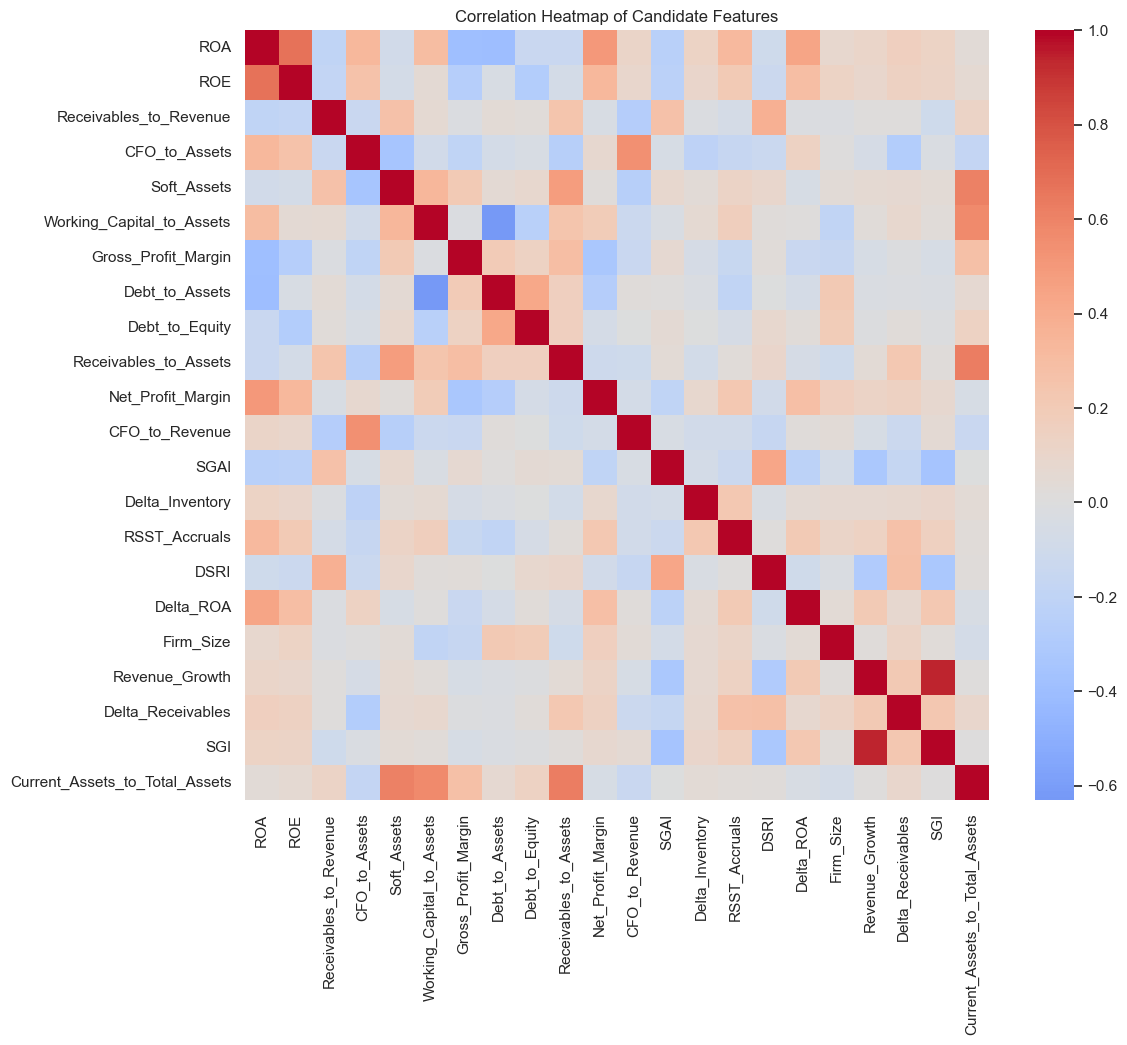

In [7]:
X_corr_stage = X_vt[corr_selected_features].copy()

plt.figure(figsize=(12, 10))
sns.heatmap(X_corr_stage.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Candidate Features")
plt.show()

In [8]:
corr_matrix = X_corr_stage.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_threshold = 0.80
to_drop = set()

for col in upper_triangle.columns:
    high_corr_features = upper_triangle.index[upper_triangle[col] > high_corr_threshold].tolist()
    
    for row_feature in high_corr_features:
        row_score = abs(corr_with_target[row_feature])
        col_score = abs(corr_with_target[col])
        
        if row_score >= col_score:
            to_drop.add(col)
        else:
            to_drop.add(row_feature)

selected_after_corr = [col for col in X_corr_stage.columns if col not in to_drop]

print("Removed due to multicollinearity:")
print(sorted(to_drop) if to_drop else "None")

print("\nRemaining features:", len(selected_after_corr))
print(selected_after_corr)

Removed due to multicollinearity:
['SGI']

Remaining features: 21
['ROA', 'ROE', 'Receivables_to_Revenue', 'CFO_to_Assets', 'Soft_Assets', 'Working_Capital_to_Assets', 'Gross_Profit_Margin', 'Debt_to_Assets', 'Debt_to_Equity', 'Receivables_to_Assets', 'Net_Profit_Margin', 'CFO_to_Revenue', 'SGAI', 'Delta_Inventory', 'RSST_Accruals', 'DSRI', 'Delta_ROA', 'Firm_Size', 'Revenue_Growth', 'Delta_Receivables', 'Current_Assets_to_Total_Assets']


## Mutual Information Ranking

Because fraud-related patterns may be non-linear, we use mutual information to assess the predictive value of each remaining feature.

Features with higher mutual information are considered more informative for fraud detection.

In [9]:
X_mi = X_vt[selected_after_corr].copy()

mi_scores = mutual_info_classif(
    X_mi,
    y,
    random_state=42
)

mi_df = pd.DataFrame({
    "Feature": X_mi.columns,
    "Mutual_Information": mi_scores
}).sort_values("Mutual_Information", ascending=False)

display(mi_df)

,Feature,Mutual_Information
0,ROA,0.082783
1,ROE,0.068287
10,Net_Profit_Margin,0.034660
2,Receivables_to_Revenue,0.027832
3,CFO_to_Assets,0.025947
12,SGAI,0.024818
18,Revenue_Growth,0.021169
11,CFO_to_Revenue,0.015106
7,Debt_to_Assets,0.013773
4,Soft_Assets,0.013090


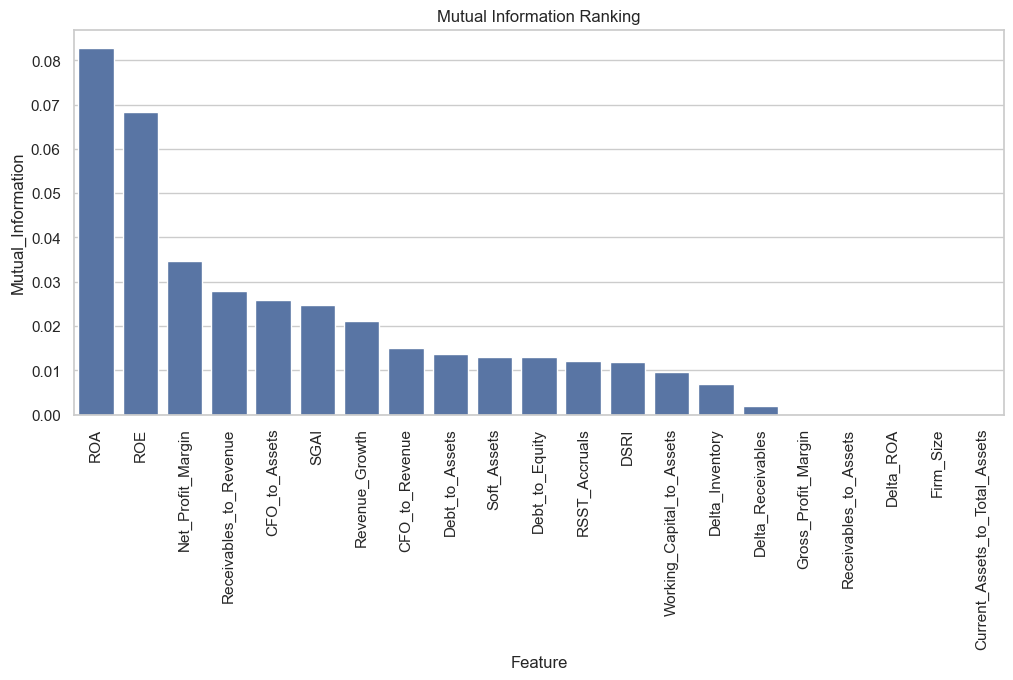

In [10]:
plt.figure(figsize=(12, 5))
sns.barplot(data=mi_df, x="Feature", y="Mutual_Information")
plt.xticks(rotation=90)
plt.title("Mutual Information Ranking")
plt.show()

## Final Feature Set

The final feature set is selected based on:

- acceptable variance,
- non-trivial association with the target,
- reduced multicollinearity,
- and mutual information ranking.

These selected variables will be used in the modeling stage.

In [11]:
top_k = 12
selected_features = mi_df.head(top_k)["Feature"].tolist()

print("Final selected features:")
print(selected_features)
print("Number of selected features:", len(selected_features))

Final selected features:
['ROA', 'ROE', 'Net_Profit_Margin', 'Receivables_to_Revenue', 'CFO_to_Assets', 'SGAI', 'Revenue_Growth', 'CFO_to_Revenue', 'Debt_to_Assets', 'Soft_Assets', 'Debt_to_Equity', 'RSST_Accruals']
Number of selected features: 12


In [12]:
X_selected = df[selected_features].copy()
y_selected = df[target_col].copy()

print("Selected feature matrix shape:", X_selected.shape)
display(X_selected.head())

Selected feature matrix shape: (1906, 12)


,ROA,ROE,Net_Profit_Margin,Receivables_to_Revenue,CFO_to_Assets,SGAI,Revenue_Growth,CFO_to_Revenue,Debt_to_Assets,Soft_Assets,Debt_to_Equity,RSST_Accruals
0,-0.018295,-0.042918,-0.062762,0.413736,0.083650,0.959822,-0.113346,0.286968,0.573722,0.707667,1.345887,0.081258
1,0.049644,0.072620,0.013214,0.027918,0.192490,1.078348,-0.080158,0.051235,0.316386,0.702721,0.462813,0.178462
2,-0.030459,-0.063284,-0.049804,0.128463,-0.119212,0.965435,-0.012514,-0.194930,0.518703,0.692532,1.077719,0.024237
3,0.031212,0.070713,0.006405,0.087645,0.207064,0.717813,0.157163,0.042492,0.558614,0.906885,1.265589,0.020757
4,0.025293,0.044905,0.050892,0.514868,0.061342,1.122113,-0.006888,0.123425,0.436737,0.452033,0.775369,0.014201


## Save Modeling Dataset

The selected features are saved to create a compact modeling dataset for the next notebook.

In [13]:
model_df = df[["CP", "Năm"] + selected_features + ["Fraud"]].copy()
model_df.to_excel(DATA_PATH / "model_data.xlsx", index=False)

print("Saved model_data.xlsx")
print("Shape:", model_df.shape)

Saved model_data.xlsx
Shape: (1906, 15)


## Feature Selection Summary

The feature selection process reduces the original set of financial variables to a smaller and more informative subset.

The final selection retains variables that:
- show meaningful association with fraud,
- provide non-linear predictive information,
- and avoid excessive redundancy.

This refined feature set will be used in the next stage to build and evaluate fraud detection models.